# Epsilon-fill modes — byte-identical tiled fill (`eps_fill`)

With `epsilon > 0`, `DEM.fill_depressions` tilts filled flats so every cell has somewhere to drain
(no plateaus) — the surface you need before D8 routing. This PR makes the `epsilon > 0` gradient a single,
deterministic definition shared by the in-memory and tiled engines, selected by `eps_fill`:

- **`eps_fill="exact"`** (default, alias `"monotone"`) — the *exit-distance ramp*
  `fill_0 + epsilon * exit_distance`. Identical in-memory and tiled, so `engine="auto"` is consistent and the
  tiled result is **byte-for-byte identical** to the in-memory one. Flat-free for *small* `epsilon`.
- **`eps_fill="barnes"`** — the classic Barnes 2014 Priority-Flood step-count. Flat-free for *any* `epsilon`,
  but it depends on the global traversal order, so it is **in-memory only** (the tiled engine rejects it).

See `docs/eps-fill-exact-feasibility.md` for why a byte-identical *tiled* Barnes step-count is ill-posed.

In [1]:
import os
import tempfile

import numpy as np
from pyramids.dataset import Dataset

from digitalrivers import DEM

# A small synthetic DEM: random relief with a broad flat depression and a deeper inner pit.
rng = np.random.default_rng(0)
elev = rng.uniform(40.0, 60.0, size=(60, 60)).astype(np.float32)
elev[15:45, 15:45] = 30.0   # broad flat depression (epsilon>0 must ramp across it)
elev[28:32, 28:32] = 20.0   # deeper inner pit

WORK = tempfile.mkdtemp(prefix="dr_eps_")
path = os.path.join(WORK, "dem.tif")
Dataset.create_from_array(
    elev, top_left_corner=(0, 0), cell_size=1.0, epsg=4326,
    no_data_value=-9999.0, driver_type="GTiff", path=path,
).close()
dem = DEM(Dataset.read_file(path).raster)
print(f"DEM: {dem.rows} x {dem.columns}, elevation {elev.min():.0f}-{elev.max():.0f}")

2026-06-09 00:38:49 | INFO | pyramids.base.config | Logging is configured.


DEM: 60 x 60, elevation 20-60


## `eps_fill="exact"` is byte-identical across engines

Force `engine="tiled"` with several small `tile_size`s (so the depression straddles tile seams) and compare to
the whole-array in-memory fill. The ramp is reconstructed exactly across seams, so the results match bit-for-bit.

In [2]:
in_mem = dem.fill_depressions(method="priority_flood", epsilon=1e-3, engine="in_memory")
ref = np.asarray(in_mem.read_array())

ok = True
for ts in (8, 16, (10, 12)):
    t = dem.fill_depressions(
        method="priority_flood", epsilon=1e-3, engine="tiled",
        out_path=os.path.join(WORK, f"t_{ts}.tif"), tile_size=ts, eps_fill="exact",
    )
    ok &= np.array_equal(np.asarray(t.read_array()), ref)
    t.close()

print("eps_fill='exact': tiled == in_memory (bit-for-bit, all tile sizes):", ok)

eps_fill='exact': tiled == in_memory (bit-for-bit, all tile sizes): True


## Visualise the epsilon ramp

`fill - fill_0` is the per-cell lift `epsilon * exit_distance`: it ramps up from the depression's drainage
exits, giving every flat cell a downhill path.

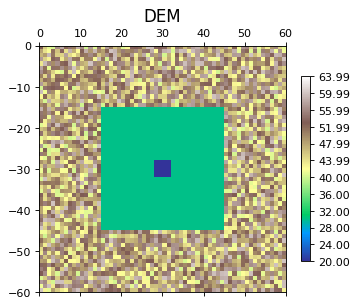

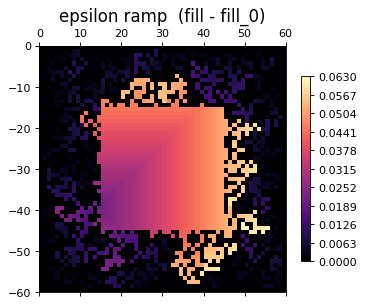

In [3]:
import matplotlib  # cleopatra (pyramids' plotting backend) renders through matplotlib

matplotlib.rcParams["figure.dpi"] = 80

# Render with pyramids' own Dataset.plot (cleopatra ArrayGlyph backend) rather than raw matplotlib.
dem.plot(band=0, title="DEM", cmap="terrain", figsize=(5, 4))

f0 = dem.fill_depressions(method="priority_flood", epsilon=0.0, engine="in_memory")
ramp = ref - np.asarray(f0.read_array())

# Wrap the derived ramp array in a Dataset so it plots through the same pyramids machinery.
Dataset.dataset_like(dem, ramp.astype(np.float32)).plot(
    band=0, title="epsilon ramp  (fill - fill_0)", cmap="magma", figsize=(5, 4)
)
f0.close()

## `eps_fill="barnes"` — the classic step-count (in-memory only)

`"barnes"` is a genuinely different surface. It guarantees a flat-free result for **any** `epsilon`, whereas the
`"exact"` ramp only guarantees that for small `epsilon`. Because it depends on the global priority-flood order it
is not tileable — `engine="tiled"` rejects it.

In [4]:
def interior_flats(s):
    n = 0
    for i in range(1, s.shape[0] - 1):
        for j in range(1, s.shape[1] - 1):
            if not (s[i - 1:i + 2, j - 1:j + 2] < s[i, j]).any():
                n += 1
    return n

big = 0.1  # a deliberately large epsilon
exact_big = dem.fill_depressions(method="priority_flood", epsilon=big, engine="in_memory", eps_fill="exact")
barnes_big = dem.fill_depressions(method="priority_flood", epsilon=big, engine="in_memory", eps_fill="barnes")

print("barnes differs from exact:", not np.array_equal(
    np.asarray(exact_big.read_array()), np.asarray(barnes_big.read_array())))
print("interior flats @ eps=0.1, exact :", interior_flats(np.asarray(exact_big.read_array())))
print("interior flats @ eps=0.1, barnes:", interior_flats(np.asarray(barnes_big.read_array())))
exact_big.close(); barnes_big.close()

barnes differs from exact: True
interior flats @ eps=0.1, exact : 46
interior flats @ eps=0.1, barnes: 0


In [5]:
# The tiled engine cannot reproduce the order-dependent step-count, so it raises.
try:
    dem.fill_depressions(
        method="priority_flood", epsilon=0.1, engine="tiled",
        out_path=os.path.join(WORK, "b.tif"), eps_fill="barnes",
    )
except NotImplementedError as exc:
    print("tiled eps_fill='barnes' ->", type(exc).__name__)
    print(str(exc).split(":")[0])

tiled eps_fill='barnes' -> NotImplementedError
eps_fill='barnes' (the classic Priority-Flood step-count) is not tileable


## Integer DEMs (e.g. int16 SRTM)

`epsilon > 0` produces a *fractional* ramp, so an integer DEM is promoted to float for the result (otherwise the
gradient would truncate away). Both engines do this identically, so they stay byte-identical on integer sources.

In [6]:
iarr = np.full((30, 30), 100, dtype=np.int16)
iarr[8:22, 8:22] = 50
iarr[14, 14] = 10
ipath = os.path.join(WORK, "int.tif")
Dataset.create_from_array(
    iarr, top_left_corner=(0, 0), cell_size=1.0, epsg=4326,
    no_data_value=-32768, driver_type="GTiff", path=ipath,
).close()
idem = DEM(Dataset.read_file(ipath).raster)

ii = idem.fill_depressions(method="priority_flood", epsilon=1e-3, engine="in_memory")
it = idem.fill_depressions(
    method="priority_flood", epsilon=1e-3, engine="tiled",
    out_path=os.path.join(WORK, "int_t.tif"), tile_size=8, eps_fill="exact",
)
ia, ib = np.asarray(ii.read_array()), np.asarray(it.read_array())

print("int16 source -> filled dtype:", ia.dtype, "(promoted; ramp preserved)")
print("distinct values in the filled pit:", np.unique(ia[8:22, 8:22]).size, "(>1 = real gradient)")
print("tiled == in_memory:", np.array_equal(ia, ib))
ii.close(); it.close(); idem.close()

int16 source -> filled dtype: float64 (promoted; ramp preserved)
distinct values in the filled pit: 7 (>1 = real gradient)
tiled == in_memory: True


## Summary

| `eps_fill`            | engines        | flat-free            | tiled == in-memory |
|-----------------------|----------------|----------------------|--------------------|
| `"exact"` / `"monotone"` (default) | in-memory + tiled | small `epsilon` | **yes, bit-for-bit** |
| `"barnes"`            | in-memory only | any `epsilon`        | n/a (tiled rejects) |

Use the default `"exact"` for out-of-core work and consistent `engine="auto"` results; use `"barnes"` in-memory
when you need a guaranteed flat-free surface at a large `epsilon`.

In [7]:
dem.close(); in_mem.close()